# Flow-corrected posterior marginalizing over WN

In [1]:
import sys
sys.path.append('..') 

import discovery as ds
import discovery.flow as dsf
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import StandardNormal
import pandas as pd
import numpy as np
import jax
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.scipy as jsp
from fourierpta import *
from numpyro import infer

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
npsr = 1
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True
)


In [3]:
psrs = allpsrs[26:27]
Tspan = ds.getspan(psrs)

In [4]:
psrs

[<Pulsar J1125+7819: 8723 res, 95 pars>]

In [5]:
psr_noisedict = psrs[0].noisedict
# only fix the equads and ecorrs
psr_noisedict_fixed = {k: v for k, v in psr_noisedict.items() if 't2equad' in k or 'ecorr' in k}

In [ ]:

def fouriermodel(psrs, rn_components, rn_init_params, noisedict, fixed_wn=True, tnequad = False, ecorr=False, powerlaw=ds.flat_tail_powerlaw):

    # modified from the fcn in fourierpta.py to also alter WN initial parameters by passing noisedict
    
    Tspan = ds.getspan(psrs)

    expected_params = [p for p in inspect.signature(powerlaw).parameters if p not in ('f', 'df')]

    if isinstance(rn_init_params, dict):
        params_list = [rn_init_params] * len(psrs)
    elif isinstance(rn_init_params, list):
        if len(rn_init_params) != len(psrs):
            raise ValueError(
                f"rn_init_params list length ({len(rn_init_params)}) must match number of pulsars ({len(psrs)})"
            )
        params_list = rn_init_params
    else:
        params_list = [{}] * len(psrs)

    for i, params in enumerate(params_list):
        if params and set(params.keys()) != set(expected_params):
            raise ValueError(
                f"Pulsar {i}: {powerlaw.__name__} expects params {expected_params} but got {list(params.keys())}")

    if fixed_wn:
        pslmodels = [ds.PulsarLikelihood([psr.residuals,
                                          ds.makegp_timing(psr, svd=True),
                                          ds.makenoise_measurement(psr, noisedict=noisedict, tnequad = tnequad, ecorr=ecorr),
                                          ds.makegp_fourier(psr, ds.partial(powerlaw, **params),
                                                            rn_components, name='red_noise', T=Tspan)])
                     for psr, params in zip(psrs, params_list)]
    else:
        pslmodels = [ds.PulsarLikelihood([psr.residuals,
                                          ds.makegp_timing(psr, svd=True),
                                          ds.makenoise_measurement(psr, ecorr=ecorr),
                                          ds.makegp_fourier(psr, ds.partial(powerlaw, **params),
                                                            rn_components, name='red_noise', T=Tspan)])
                     for psr, params in zip(psrs, params_list)]

    return pslmodels


In [8]:
psr_noisedict = psrs[0].noisedict
broad_noisedict = psr_noisedict

for k in broad_noisedict:
    if 'efac' in k.lower():
        broad_noisedict[k] = 1.1
    if 'equad' in k.lower() or 't2equad' in k.lower():
        broad_noisedict[k] = -8
    if 'ecorr' in k.lower():
        broad_noisedict[k] = -4.5

psr_noisedict = broad_noisedict

In [9]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw
#rn_init_params =  extract_rn_params(psrs)
rn_init_params = [{'log10_A': -13.0, 'gamma': 6.5}]
N = 10000
ecorr = True 
fixed_wn = False

psr_noisedict = broad_noisedict

# Creating the HD Fourier model
pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, noisedict = psr_noisedict, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)


In [10]:
ds.priordict_standard
newdict = {'(.*_)?red_noise_coefficients\\(([0-9]*)\\)': [-100, 100]} # just much broader than we'll encounter

In [11]:
Ls, sigma0_inv_blocks, ahat0_list = [], [], []
logdet_sigma0_inv = 0.0

for psr_model in pslmodels:

            ahat0, cf_inv = psr_model.conditional(psr_noisedict)
            
            sigma0_inv_psr = cf_inv[0] @ cf_inv[0].T
            logdet_sigma0_inv += 2.0 * jnp.sum(jnp.log(jnp.diag(cf_inv[0])))
            
            sigma0_psr = jsp.linalg.cho_solve((cf_inv[0], True), jnp.eye(cf_inv[0].shape[0]))
            L_sigma0 = jsp.linalg.cholesky(sigma0_psr, lower=True)
            
            Ls.append(L_sigma0)
            sigma0_inv_blocks.append(sigma0_inv_psr)
            ahat0_list.append(ahat0)
            

In [12]:
import numpyro
import numpyro.distributions as dist


In [13]:
import re
def simple_dict_transformation(func,priordict=newdict):
    """change from dictionary as input to list of arrays as input

    Parameters
    ----------
    func : discovery likelihood
        discovery likelihood function
    """
    priordict = {**ds.priordict_standard, **priordict}

    # figure out slices when there are vector arguments
    slices, offset = [], 0

    for par in func.params:
        if '(' in par:
            l = int(par[par.index('(')+1:par.index(')')]) if '(' in par else 1
            slices.append(slice(offset, offset+l))
            offset = offset + l
        else:
            slices.append(offset)
            offset = offset + 1
    # build vectors of DF column names and of lower and upper uniform limits
    a, b = [], []
    columns = []
    for par, slice_ in zip(func.params, slices):
        for pname, prange in priordict.items():
            if re.match(pname, par):
                therange = prange
                break
        else:
            raise KeyError(f"No known prior for {par}.")

        if '(' in par:
            root = par[:par.index('(')]
            l = int(par[par.index('(')+1:par.index(')')]) if '(' in par else 1

            for i in range(l):
                columns.append(f'{root}[{i}]')
                a.append(therange[0])
                b.append(therange[1])
        else:
            columns.append(par)
            a.append(therange[0])
            b.append(therange[1])
    a, b = ds.matrix.jnparray(a), ds.matrix.jnparray(b)

    def to_dict_and_jacobian(ys, ahat, L):
        hyper_pars = [p for p in func.params if "coefficients" not in p]
        coeff_pars = [p for p in func.params if "coefficients" in p]
        len_hyper = len(hyper_pars)

        if len_hyper > 0:
            ys_hyper = ys[:len_hyper]
            xs_hyper = 0.5 * (b[:len_hyper] + a[:len_hyper] + 
                            (b[:len_hyper] - a[:len_hyper]) * jnp.tanh(ys_hyper))
            hyper_jacobian = jnp.sum(jnp.log(2.0) - 2.0 * jnp.logaddexp(ys_hyper, -ys_hyper))
            hyper_dict = dict(zip(hyper_pars, jnp.array(xs_hyper).T))
        else:
            hyper_jacobian = 0.0
            hyper_dict = {}

        jac = jnp.sum(jnp.log(jnp.diag(L)))
        coeff_idx = func.params.index(coeff_pars[0])
        xs_coeff = L @ ys[slices[coeff_idx]] + ahat
        hyper_dict.update({coeff_pars[0]: xs_coeff})

        return hyper_dict, jac + hyper_jacobian

        
    def transformed(ys, ahat, L):
        mydict, jac = to_dict_and_jacobian(ys, ahat, L)
        return func(mydict) + jac
    
    transformed.params = func.params
    transformed.to_dict_and_jacobian = to_dict_and_jacobian
    transformed.a_bounds = a
    transformed.b_bounds = b
    transformed.columns = columns
    
    return transformed

In [14]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

In [15]:
L0 = Ls[0]

In [16]:
pslmodels[0].clogL.params

['J1125+7819_Rcvr1_2_GUPPI_efac',
 'J1125+7819_Rcvr1_2_GUPPI_log10_ecorr',
 'J1125+7819_Rcvr1_2_GUPPI_log10_t2equad',
 'J1125+7819_Rcvr_800_GUPPI_efac',
 'J1125+7819_Rcvr_800_GUPPI_log10_ecorr',
 'J1125+7819_Rcvr_800_GUPPI_log10_t2equad',
 'J1125+7819_red_noise_coefficients(60)']

### Sampling $p(a, \theta | \eta_0)$

In [ ]:
logL_test = logxs[0]
hyper_pars = [p for p in logL_test.params if "coefficients" not in p]
hyper_indices = jnp.array([logL_test.columns.index(p) for p in hyper_pars])
a_hyper = logL_test.a_bounds[hyper_indices]
b_hyper = logL_test.b_bounds[hyper_indices]

low  = jnp.array([0.9 if "efac" in p else -8.5 for p in hyper_pars])
high = jnp.array([1.1 if "efac" in p else -5.0 for p in hyper_pars])

def model_test():
    xs_hyper = numpyro.sample("eta", dist.Uniform(low, high))
    y_hyper = jnp.arctanh((2.0 * xs_hyper - b_hyper - a_hyper) / (b_hyper - a_hyper))

    xi = numpyro.sample("xi", dist.Normal(jnp.zeros(60), jnp.ones(60)))
    numpyro.deterministic("a", ahat0 + L0 @ xi)

    ys = jnp.concatenate([y_hyper, xi])
    loglik = logL_test(ys, ahat0, L0) + 0.5 * jnp.dot(xi, xi)
    numpyro.factor("logL", loglik)

kernel= infer.NUTS(model_test)
sampler = infer.MCMC(kernel, num_warmup=128, num_samples=512, progress_bar=True)

init_params = {
    "eta": jnp.array([1.0 if "efac" in p else -7.0 for p in hyper_pars]),
    "xi":  jnp.zeros(60),
}

sampler.run(jax.random.key(0), init_params=init_params)
samples = sampler.get_samples()
sampler.print_summary()

sample: 100%|██████████| 640/640 [15:57<00:00,  1.50s/it, 31 steps of size 1.21e-01. acc. prob=0.97]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
    eta[0]      1.03      0.01      1.03      1.01      1.05    530.08      1.00
    eta[1]     -7.01      0.61     -6.97     -8.03     -6.12    489.32      1.00
    eta[2]     -6.59      0.46     -6.43     -7.30     -6.12     84.90      1.00
    eta[3]      1.03      0.01      1.03      1.01      1.05    706.82      1.00
    eta[4]     -5.44      0.06     -5.44     -5.53     -5.34    511.55      1.00
    eta[5]     -5.85      0.04     -5.85     -5.91     -5.80    876.49      1.00
     xi[0]     -0.48      0.28     -0.49     -0.99     -0.07    166.97      1.04
     xi[1]      0.20      0.17      0.19     -0.08      0.46    252.16      1.02
     xi[2]      0.29      0.21      0.29     -0.07      0.61    190.20      1.03
     xi[3]      0.39      0.12      0.39      0.20      0.61    487.49      1.00
     xi[4]     -0.21      0.45     -0.22     -0.89      0.51    248.19      1.01
     xi[5]      0.48      0

### Fitting flow to MCMC samples for decentered $\int d \theta p(\xi, \theta | \eta_0)$

#### Approach 1

In [18]:
from flowjax.train import fit_to_data

xi_samples = jnp.array(samples["xi"])
n_coeff = xi_samples.shape[1]

key, flow_key, train_key = jax.random.split(jax.random.key(1), 3)

flow = masked_autoregressive_flow(flow_key,
    base_dist=StandardNormal((n_coeff,)),
    flow_layers=4, nn_width=32, nn_depth=4,
    invert=True,)   # using invert = True
                    # which allows for faster logprob evaluation,
                    # see https://danielward27.github.io/flowjax/api/flows.html

trained_flow_xi, train_key = fit_to_data(train_key,dist=flow,
    data=xi_samples, learning_rate=1e-3, max_epochs=1000, batch_size = 128 )

  7%|▋         | 68/1000 [00:05<01:16, 12.13it/s, train=73.2, val=75.8 (Max patience reached)]


In [19]:
pslmodels_fixed_wn = fouriermodel(psrs, rn_components, noisedict = broad_noisedict,
                                 rn_init_params= rn_init_params, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = True)


logxs_fixed = [simple_dict_transformation(pslmodels_fixed_wn[_].clogL) for _ in range(npsr)]
logL_fixed = logxs_fixed[0]

def model_test_fixed():
    xi = numpyro.sample("xi", dist.Normal(jnp.zeros(60), jnp.ones(60)))
    numpyro.deterministic("a", ahat0 + L0 @ xi)

    loglik = logL_fixed(xi, ahat0, L0) + 0.5 * jnp.dot(xi, xi)
    numpyro.factor("logL", loglik)

kernel_fixed = infer.NUTS(model_test_fixed)
sampler_fixed = infer.MCMC(kernel_fixed, num_warmup=1000, num_samples=3000, progress_bar=True)
sampler_fixed.run(jax.random.key(0))
samples_fixed = sampler_fixed.get_samples()


sample: 100%|██████████| 4000/4000 [00:04<00:00, 868.81it/s, 7 steps of size 5.55e-01. acc. prob=0.83] 


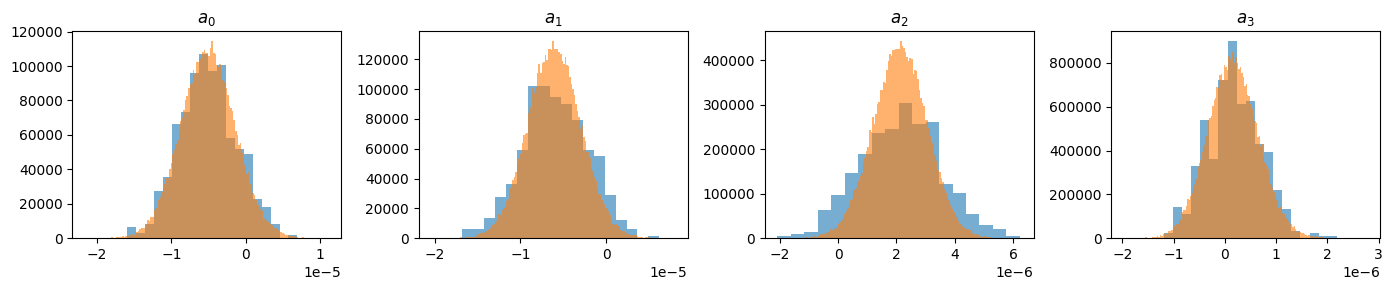

In [20]:
num_samples = 100000
a_mcmc = np.array(samples["a"])
xi_flow = jnp.array(trained_flow_xi.sample(jax.random.key(0), (num_samples,)))
a_flow  = np.array(ahat0[None, :] + (L0 @ xi_flow.T).T)

components = [0,1, 2, 3]
fig, axes = plt.subplots(1, len(components), figsize=(14, 3))

for ax, i in zip(axes, components):
    ax.hist(a_mcmc[:, i], bins='auto', density=True, alpha=0.6)
    ax.hist(a_flow[:, i], bins='auto', density=True, alpha=0.6)
    ax.set_title(rf"$a_{{{i}}}$")

plt.tight_layout()
plt.show()

#### Approach 2

Above, the RN coefficients are sampled from the joint distribution of Fourier coefficients and WN parameters, which may be slow depending on the number of white noise parameters involved. This is disadvantageous if we want to use 'fit_to_data' since we have to rely on fewer samples.

Another idea is to use variational inference to fit a flow to the joint distribution, which would allow us to generate samples using the flow efficiently, and then use the 'fit_to_data' method on a bunch of generated samples. One disadvantage with this method however is that simultaneously fitting a flow to the white noise parameters may be more difficult than fitting a flow to the white-noise marginalized distribution only. This approach also uses requires two seperate flows.

In [36]:
pslmodels[0].clogL.params

['J1125+7819_Rcvr1_2_GUPPI_efac',
 'J1125+7819_Rcvr1_2_GUPPI_log10_ecorr',
 'J1125+7819_Rcvr1_2_GUPPI_log10_t2equad',
 'J1125+7819_Rcvr_800_GUPPI_efac',
 'J1125+7819_Rcvr_800_GUPPI_log10_ecorr',
 'J1125+7819_Rcvr_800_GUPPI_log10_t2equad',
 'J1125+7819_red_noise_coefficients(60)']

In [60]:
def fit_flow_theta(logx, num_samples, rng,
                   hyper_pars, n_coeff,
                   ahat0, L0):
    
    n_hyper = len(hyper_pars)
    n_total = n_hyper + n_coeff

    def logx_theta(ys):
        # unfortunately I have to switch 
        # order of hyperparams here to make it work
        # TODO: fix this!
        y_hyper = ys[:n_hyper]
        y_coeff = ys[n_hyper:]

        ys_full = jnp.concatenate([y_coeff, y_hyper])
        return logx(ys_full, ahat0, L0)

    flow_key, train_key = jax.random.split(rng, 2)

    loss = dsf.value_and_grad_ElboLoss(logx_theta, num_samples=num_samples)

    flow = masked_autoregressive_flow(
        flow_key, base_dist=StandardNormal((n_total,)),
        flow_layers=6, nn_width=32, nn_depth=6, # slightly more complex for WN
        invert=True)

    trainer = dsf.VariationalFit(
        dist=flow, loss_fn=loss, multibatch=1,
        learning_rate=1e-2,
        annealing_schedule=lambda i: min(1.0, 0.5 + 0.5*i/25),
        show_progress=True)

    train_key, trained_flow = trainer.run(train_key, steps=1001)
    return train_key, trained_flow, trainer

logL_test = logxs[0]
hyper_pars = [p for p in logL_test.params if "coefficients" not in p]
hyper_indices = jnp.array([logL_test.columns.index(p) for p in hyper_pars])
a_hyper = logL_test.a_bounds[hyper_indices]
b_hyper = logL_test.b_bounds[hyper_indices]

num_samples = 64
rng = jax.random.key(0)

trained_flows_opt2 = []
train_keys = []

for i in range(npsr):
    print(f"Fitting joint flow for pulsar {pslmodels[i].name}")
    rng, subkey = jax.random.split(rng)
    train_key, trained_flow, trainer = fit_flow_theta(
        logxs[i], num_samples, subkey, hyper_pars,
        n_coeff=2*rn_components, ahat0 = ahat0_list[i], L0 = Ls[i])
    trained_flows_opt2.append(trained_flow)
    train_keys.append(train_key)

Fitting joint flow for pulsar J1125+7819


 33%|███▎      | 334/1001 [19:35<39:08,  3.52s/it, loss=-92705.35] 

Early stopping at iteration 334


In [63]:
# gnerate samples from the joint flow
ys_flow = trained_flows_opt2[0].sample(jax.random.key(1), (10000,))
xi_samples_opt2 = ys_flow[:, len(hyper_pars):]

# use fit_to_data
trained_flow_xi_opt2, train_key = fit_to_data(jax.random.key(0),dist=flow,
    data=xi_samples_opt2, learning_rate=1e-3, max_epochs=1000, batch_size = 128 )

a_flow_opt2 = np.array(ahat0_list[0][None, :] + (Ls[0] @ xi_samples_opt2.T).T)

  1%|          | 12/1000 [00:12<16:46,  1.02s/it, train=57.2, val=57 (Max patience reached)]


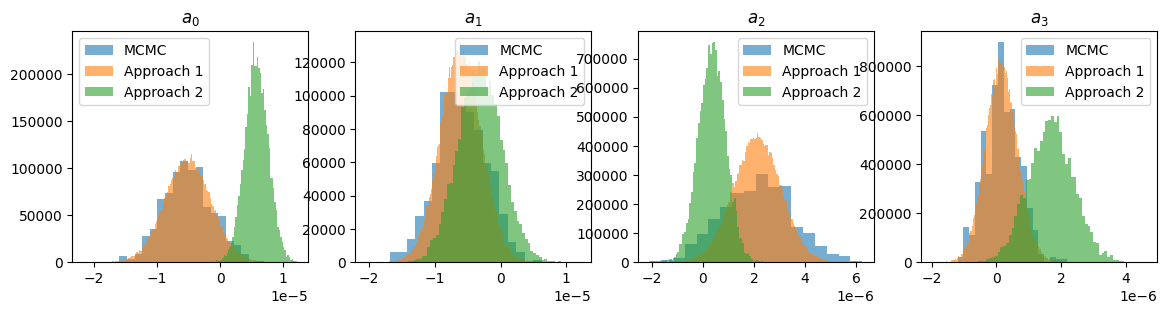

In [64]:
# plot opt 1 vs opt in a space
components = [0,1, 2, 3]
fig, axes = plt.subplots(1, len(components), figsize=(14, 3))
for ax, i in zip(axes, components):
    ax.hist(a_mcmc[:, i], bins='auto', density=True, alpha=0.6, label='MCMC')
    ax.hist(a_flow[:, i], bins='auto', density=True, alpha=0.6, label='Approach 1')
    ax.hist(a_flow_opt2[:, i], bins='auto', density=True, alpha=0.6, label='Approach 2')
    ax.set_title(rf"$a_{{{i}}}$")
    ax.legend()

In [70]:
y_samples_theta =  ys_flow[:, :len(hyper_pars)]
y_samples_theta = ys_flow[:, :len(hyper_pars)]
xs_theta = 0.5 * (b_hyper + a_hyper + (b_hyper - a_hyper) * jnp.tanh(y_samples_theta))
theta_names = [p for p in logL_test.params if "coefficients" not in p]
theta_dict =  dict(zip(theta_names, xs_theta.T))

In [74]:
samples

{'a': Array([[-6.24903479e-06, -7.81481572e-06,  2.68361324e-06, ...,
          4.83156536e-10,  3.07059838e-10, -9.75478428e-10],
        [-4.85401677e-06, -6.54980583e-06,  1.61075821e-06, ...,
         -5.80142562e-10, -2.95567393e-10,  3.09182134e-10],
        [-3.13180553e-06, -5.15350872e-06,  2.28409588e-06, ...,
         -5.65094080e-10, -2.23720500e-10,  9.27934527e-10],
        ...,
        [-1.21153246e-05, -1.27777830e-05,  4.27217979e-06, ...,
          2.26281557e-10, -2.99264120e-10, -6.19402201e-10],
        [-7.57021250e-06, -7.01348982e-06,  2.62013907e-06, ...,
          6.39911725e-11, -1.21115907e-10,  9.66149852e-10],
        [-5.12356788e-06, -5.11385260e-06,  2.01075797e-06, ...,
         -3.71949821e-10, -3.58241466e-10,  8.66486592e-10]],      dtype=float64),
 'eta': Array([[ 1.01711587, -7.05125091, -6.27493633,  1.03974816, -5.41444233,
         -5.8567758 ],
        [ 1.03018976, -6.08377536, -6.3200965 ,  1.0288897 , -5.48802603,
         -5.8152376 ],
   

In [75]:
mcmc_samples = np.array(samples["eta"])

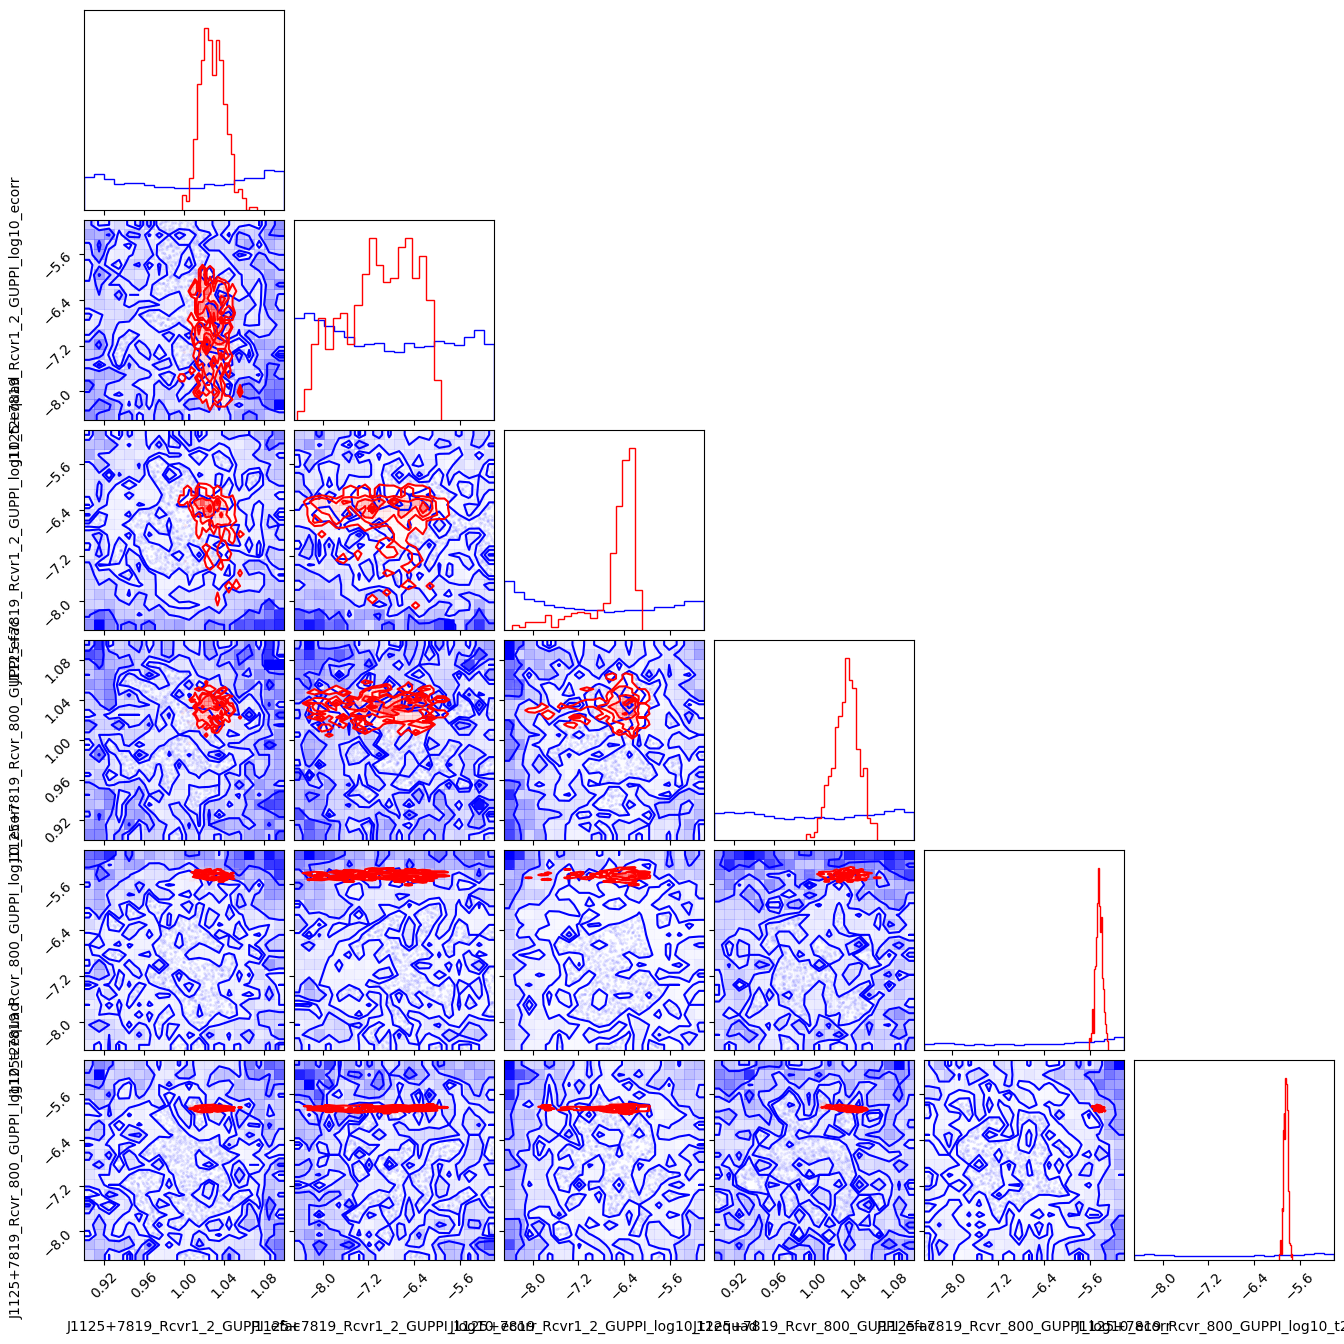

In [76]:
figure  = corner.corner(theta_dict, hist_kwargs={'density': True, 'color': 'blue'}, color = 'blue')
corner.corner(mcmc_samples, hist_kwargs={'density': True, 'color': 'red'}, color = 'red', fig=figure)
plt.show()

I am not able to find the cause for this mismatch for now, and for this reason I will proceed with the first approach in the multipulsar implementation.

### Comparing distribution of $a$'s from fixed WN and flow with varying WN

In [21]:
_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

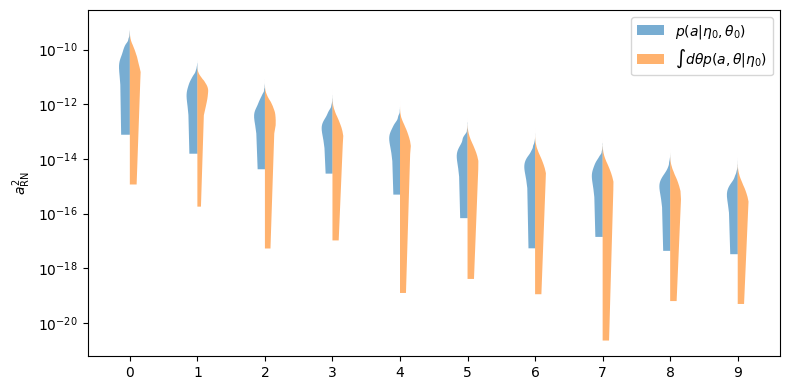

In [22]:
from matplotlib.ticker import LogFormatter, NullFormatter
from matplotlib.patches import Patch

def compute_power(a):
    a_pairs = a.reshape(a.shape[0], rn_components, 2)
    return np.sum(a_pairs**2, axis=-1) 

power_mcmc = compute_power(a_mcmc)
power_flow = compute_power(a_flow) 

n_plot = 10
freq_idx = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(8, 4))

vp1 = ax.violinplot([power_mcmc[:, k] for k in range(n_plot)],
                    positions=freq_idx, widths=4 * 0.08,
                    showmeans=False, showextrema=False)

vp2 = ax.violinplot([power_flow[:, k] for k in range(n_plot)],
                    positions=freq_idx, widths=4 * 0.08,
                    showmeans=False, showextrema=False)

for k, (b1, b2) in enumerate(zip(vp1["bodies"], vp2["bodies"])):
    center = freq_idx[k]
    verts1 = b1.get_paths()[0].vertices
    verts1[:, 0] = np.minimum(verts1[:, 0], center)
    b1.set_alpha(0.6)
    verts2 = b2.get_paths()[0].vertices
    verts2[:, 0] = np.maximum(verts2[:, 0], center)
    b2.set_alpha(0.6)

# freq_positions by idx
freq_idx = np.arange(n_plot)
ax.set_yscale('log')
ax.set_xticks(freq_idx)
ax.xaxis.set_minor_formatter(NullFormatter())
#ax.set_xlabel("f [Hz]")
ax.set_ylabel(r"$a_\mathrm{RN}^2$")

legend_elements = [Patch(facecolor='C0', alpha=0.6, label=r'$p(a|\eta_0, \theta_0)$'),
                   Patch(facecolor='C1', alpha=0.6, label=r'$\int d\theta p(a, \theta |\eta_0)$')]
ax.legend(handles=legend_elements)
plt.savefig(r"marginalized_wn_a_coeffs.png")
plt.tight_layout()
plt.show()

### Estimating $\hat a_f, \Sigma_f$

In [23]:
ahat_flow = jnp.mean(a_flow, axis = 0)
Sigma_flow = jnp.cov(a_flow.T)

L_flow = jnp.linalg.cholesky(Sigma_flow)
Sigma_flow_inverse = jnp.linalg.inv(Sigma_flow)

logdet_sigma_flow_inv = -2.0 * jnp.sum(jnp.log(jnp.diag(L_flow)))
b_flow = Sigma_flow_inverse @ ahat_flow
quad0 = ahat_flow @ b_flow

if isinstance(rn_init_params, dict):
        params_list = [rn_init_params] * len(psrs)
elif isinstance(rn_init_params, list):
        if len(rn_init_params) != len(psrs):
            raise ValueError(
                f"rn_init_params list length ({len(rn_init_params)}) must match number of pulsars ({len(psrs)})"
            )
        params_list = rn_init_params
else:
        params_list = [{}] * len(psrs)
      
_, f, df = construct_freqs(psrs, num_frequencies=rn_components)
  
phi0_inv_blocks, logdet_phi0 = [], 0.0
for params in params_list:
    phi0_inv_i, logdet_phi0_i = phi_sp(params, f, df, powerlaw)
    phi0_inv_blocks.append(phi0_inv_i)
    logdet_phi0 += logdet_phi0_i
        
TNT_flow = Sigma_flow_inverse - phi0_inv_blocks[0]

In [24]:
# Creating keys for the rn params + gw params
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

In [25]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
commongp_crn =ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])
getN_common = commongp.Phi.getN 
getN_crn = commongp_crn.Phi.getN

In [26]:
phi_crn_args = (crn_components, rn_amp_keys, rn_gamma_keys, crn_log10A_key, 
        crn_gamma_key, getN_common, getN_crn)

phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

In [27]:
ahat0 = ahat0.reshape(1,60)
L0 = L0.reshape(1,60,60)

### Running CRN with flow-corrected posterior

In [31]:
import numpyro
import numpyro.distributions as dist
from numpyro import infer

def make_model_crn_flow(b, phi, log_const, TNT, npsr, rn_components,
                  rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key,
                  logL_flow, ahat_f, L_sigma_f):

    # checking shapes for vmap when we run multiple psrs
    if TNT.shape != (npsr, 2 * rn_components, 2 * rn_components):
        TNT = TNT.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)

    if b.shape != (npsr, 2 * rn_components):
        b = b.reshape(npsr, 2 * rn_components)
        
    if L_sigma_f.shape != (npsr, 2 * rn_components, 2 * rn_components):
        L_sigma_f = L_sigma_f.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)
    
    if ahat_f.shape != (npsr, 2 * rn_components):
        ahat_f = ahat_f.reshape(npsr, 2 * rn_components)

    def model_crn():

        etas = {}
        for k in rn_amp_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(-20, -11))
        for k in rn_gamma_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(0, 7))
        etas[crn_log10A_key] = numpyro.sample(crn_log10A_key, dist.Uniform(-20, -11))
        etas[crn_gamma_key]  = numpyro.sample(crn_gamma_key,  dist.Uniform(0, 7))

        xi = numpyro.sample("xi", dist.Normal(jnp.zeros(npsr * 2 * rn_components),
                                                jnp.ones(npsr * 2 * rn_components)))
        xis = xi.reshape(npsr, 2 * rn_components)

        phi_inv_diags, logdet_phi = phi(etas)

        sigma_inv = TNT + jax.vmap(jnp.diag)(phi_inv_diags)
        L_sinv = jax.vmap(jnp.linalg.cholesky)(sigma_inv)
        ahat = jax.vmap(lambda l0, b: jsp.linalg.cho_solve((l0, True), b))(L_sinv, b)
        Sigma = jax.vmap(lambda l0: jsp.linalg.cho_solve((l0, True), 
                                jnp.eye(2 * rn_components)))(L_sinv)
        L_sigma = jax.vmap(jnp.linalg.cholesky)(Sigma) 

        a = numpyro.deterministic("a", ahat + jax.vmap(jnp.dot)(L_sigma, xis))

        quad_b = jnp.sum(jax.vmap(jnp.dot)(b, ahat))
        log_det_L = -jnp.sum(jax.vmap(lambda l0: jnp.sum(jnp.log(jnp.diag(l0))))(L_sinv))
        logL = 0.5 * quad_b - 0.5 * logdet_phi + log_const + log_det_L
        
        numpyro.factor("logL", logL)

        # (new part) flow correction log p_flow(a | \rho_0) - log N(a|ahat_f, SIgma_f)       
        a_diff_0 = a - ahat0         
        y = jax.vmap(lambda l, r: jsp.linalg.solve_triangular(l, r, lower=True))(L0, a_diff_0)
        log_p_flow  = logL_flow(y.ravel())
        numpyro.deterministic("y", y)
        
        a_diff = a - ahat_f   
        y_gauss = jax.vmap(lambda l0, r: jsp.linalg.solve_triangular(l0, r, lower=True))(L_sigma_f, a_diff)
        log_p_gauss = -0.5 * jnp.sum(y_gauss**2) 
        numpyro.deterministic("y_gauss", y_gauss)
        
        logFlow_correction = log_p_flow - log_p_gauss 
        numpyro.factor("logFlow_correction", logFlow_correction)
        
    return model_crn

ahat_f = jnp.array(ahat_flow)
L_sigma_f = L_flow

logL_flow = trained_flow_xi.log_prob
base_model_args = (b_flow, phi_crn_partial, 0.5 * logdet_phi0, TNT_flow, npsr, rn_components,
                   rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key)

flow_model_spa = make_model_crn_flow(*base_model_args, logL_flow=logL_flow,
                                      ahat_f=ahat_f, L_sigma_f=L_sigma_f,)
 
init_params = {crn_gamma_key: 2.0, crn_log10A_key: -17.0,      
    f"{pslmodels[0].name}_red_noise_gamma": rn_init_params[0]['gamma'],
    f"{pslmodels[0].name}_red_noise_log10_A": rn_init_params[0]['log10_A'],
    "xi": jnp.zeros(npsr * 2 * rn_components),}

kernel_flow  = infer.NUTS(flow_model_spa)
sampler_flow = infer.MCMC(kernel_flow, num_warmup=1000, num_samples=2000)
sampler_flow.run(jax.random.PRNGKey(2), init_params = init_params)

samples_flow = sampler_flow.get_samples()
sampler_flow.print_summary()

sample: 100%|██████████| 3000/3000 [03:11<00:00, 15.68it/s, 31 steps of size 1.41e-01. acc. prob=0.90]


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1125+7819_red_noise_gamma      3.53      1.99      3.64      0.67      6.98   1669.29      1.00
  J1125+7819_red_noise_log10_A    -17.12      1.67    -17.11    -19.87    -14.80    827.15      1.00
                     crn_gamma      3.45      1.96      3.37      0.60      6.77   1575.24      1.00
                   crn_log10_A    -16.93      1.81    -16.92    -19.95    -14.44   1030.25      1.00
                         xi[0]     -0.04      1.02     -0.01     -1.64      1.64   1592.79      1.00
                         xi[1]      0.02      1.01      0.03     -1.72      1.62   1681.82      1.00
                         xi[2]     -0.01      1.00     -0.01     -1.74      1.51   1535.47      1.00
                         xi[3]     -0.04      1.01     -0.05     -1.68      1.65   1639.95      1.00
                         xi[4]     -0.01      1.00      0.00     -1.68      1.52   1476.93

In [32]:
m_crn = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=broad_noisedict, ecorr=ecorr)]) for psr in psrs],
            commongp = [ds.makecommongp_fourier(psrs, ds.powerlaw, components=rn_components, T=Tspan, name='red_noise'),
                        ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])])

In [33]:
def log_prior_rho_crn(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds_crn(rho):
        lp = log_prior_rho_crn(rho)
        return - m_crn.logL(rho) - lp
    
kernel_ds_crn = infer.NUTS(potential_fn=potential_ds_crn)
sampler_ds_crn = infer.MCMC(kernel_ds_crn, num_warmup=1000, num_samples=2000, num_chains=1, progress_bar=True)
init_rho_crn = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0,
    crn_gamma_key: 4.0}

sampler_ds_crn.run(jax.random.key(1), init_params=init_rho_crn)

samples_ds_crn = sampler_ds_crn.get_samples()
sampler_ds_crn.print_summary()


sample: 100%|██████████| 3000/3000 [03:09<00:00, 15.81it/s, 211 steps of size 1.05e-02. acc. prob=0.96] 


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1125+7819_red_noise_gamma      3.25      2.09      3.10      0.02      6.40     74.60      1.01
  J1125+7819_red_noise_log10_A    -16.53      2.09    -16.52    -19.97    -13.65     79.39      1.00
                     crn_gamma      3.44      2.09      3.33      0.60      6.97     69.36      1.01
                   crn_log10_A    -16.87      2.18    -17.16    -20.00    -13.78     79.77      1.04

Number of divergences: 1899


In [34]:
mcmc_y = np.array(samples_flow["y"])  
mcmc_y_gauss = np.array(samples_flow["y_gauss"])       
mcmc_y_flat = mcmc_y.reshape(mcmc_y.shape[0], -1)   
mcmc_y_gauss_flat = mcmc_y_gauss.reshape(mcmc_y_gauss.shape[0], -1)

flow_ys = np.array(trained_flow_xi.sample(train_key, sample_shape=(mcmc_y.shape[0],)))  

n_dims_show = 4
fig, axes = plt.subplots(1, n_dims_show, figsize=(3 * n_dims_show, 3))

for i in range(n_dims_show):
    axes[i].hist(mcmc_y_flat[:,4+ i], bins='auto', density=True,
                 alpha=0.5, color="blue", label="MCMC")
    axes[i].hist(flow_ys[:, i], bins='auto', density=True,
                 alpha=0.5, color="red", label="Flow")
    axes[i].hist(mcmc_y_gauss_flat[:,4+ i], bins='auto', density=True,
                 alpha=0.5, color="green", label="Gaussian")
    axes[i].set_title(f"$y_{{{i}}}$")
    if i == 0:
        axes[i].legend()

plt.show()


AttributeError: 'dict' object has no attribute 'dtype'

In [ ]:
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}
corner.corner(irn_samples_flow)
plt.show()
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}
corner.corner(irn_samples_flow)
plt.show()

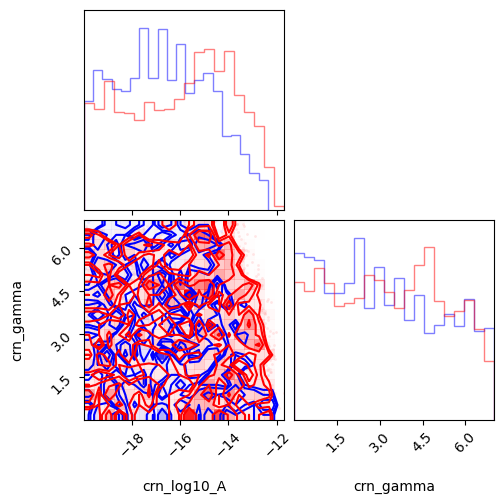

In [ ]:
crn_hyper_ds = {k: samples_ds_crn[k] for k in [crn_log10A_key, crn_gamma_key]}
crn_samples_flow = {k: samples_flow[k] for k in [crn_log10A_key, crn_gamma_key]}
figure = corner.corner(crn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color = 'blue')
corner.corner(crn_hyper_ds, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color = 'red', fig = figure)
plt.savefig(f"crn_hyper_wn_{psrs[0].name}_marginalized.png")
plt.show()

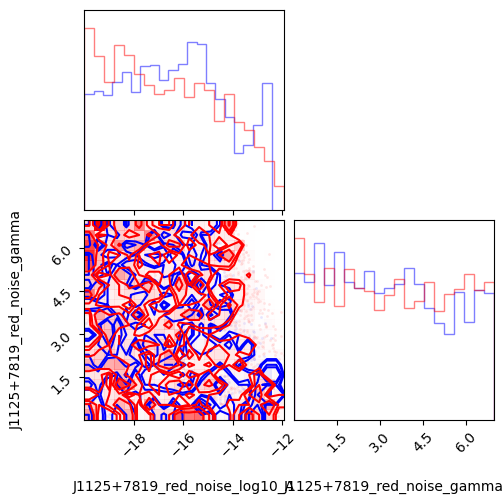

In [ ]:
irn_samples_ds_crn = {k: samples_ds_crn[k] for k in rn_amp_keys + rn_gamma_keys}
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}

figure = corner.corner(irn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color='blue')
corner.corner(irn_samples_ds_crn, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color='red', fig=figure)
plt.savefig(f"irn_hyper_flow_wn_{psrs[0].name}_marginalized.png")
plt.show()


In [ ]:
rn_log10_A_ds_crn = samples_ds_crn[crn_log10A_key]
rn_log10_A_flow = samples_flow[crn_log10A_key]

mean_ds_crn = jnp.mean(rn_log10_A_ds_crn)
mean_flow = jnp.mean(rn_log10_A_flow)

mean_ds_crn, mean_flow

(Array(-16.04712768, dtype=float64), Array(-16.68044992, dtype=float64))